# 🗑️ Municipal Waste Management — Global Analysis

Comprehensive analysis of municipal waste management data worldwide and air and water quality for the countries

**المصادر:**
- `municipal-waste-management-method.csv` — طرق إدارة النفايات لكل دولة (239 دولة، 2020)
- `share-waste-collected.csv` — نسبة النفايات التي يتم جمعها لكل دولة
- `OECD_ENV_EPI_DSD_MUNW_DF_MUNW_1_0__A_MUNICIPAL_T.csv` — إجمالي النفايات المُولَّدة (دول OECD، 2015-2024)
- `Cities.csv`  و نسب تلوث الهواء و الماء بهم - بيانات تحتوي على مؤشرَين لـ **3,937 مدينة** في **176 دولة**:


---

## Making librarers and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

##  Load data

In [2]:
cities = pd.read_csv('Cities1.csv')
print(f'  Cities Dataset:   {cities.shape}')
print()
print('Sample Cities Data:')
cities.head(3)
methods = pd.read_csv('municipal-waste-management-method.csv')

collected = pd.read_csv('share-waste-collected.csv')
collected.columns = ['Entity', 'Code', 'Year', 'Share_Collected']

oecd_raw = pd.read_csv('OECD.ENV.EPI,DSD_MUNW@DF_MUNW,1.0+.A.MUNICIPAL.T.csv')
oecd = oecd_raw[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']].copy()
oecd.columns = ['Country', 'Year', 'Waste_Tonnes_Thousands']
oecd = oecd.dropna(subset=['Waste_Tonnes_Thousands'])
oecd['Waste_Million_Tonnes'] = oecd['Waste_Tonnes_Thousands'] / 1000

print(' Dataset Shapes:')
print(f'  Waste Methods:    {methods.shape}')
print(f'  Share Collected:  {collected.shape}')
print(f'  OECD Generated:   {oecd.shape}')
print()
methods.head(3)

  Cities Dataset:   (3937, 5)

Sample Cities Data:
 Dataset Shapes:
  Waste Methods:    (239, 10)
  Share Collected:  (239, 4)
  OECD Generated:   (562, 4)



,Entity,Code,Year,Open dumps,Open burning,Controlled landfills,Sanitary landfills,Incinerated,Composted,Recycled
0,Afghanistan,AFG,2020,57.664207,36.685463,0.00,0.00,0.000000,4.214322,1.436008
1,Albania,ALB,2020,55.454403,21.115930,0.00,0.00,8.270926,3.638272,11.520468
2,Algeria,DZA,2020,2.000000,2.000000,5.84,81.88,0.000000,0.920000,7.360000


##  Basic (EDA) 

In [3]:
# Waste management summary
method_cols = ['Open dumps', 'Open burning', 'Controlled landfills',
               'Sanitary landfills', 'Incinerated', 'Composted', 'Recycled']

print('=== Waste Management ===')
avgs = methods[method_cols].mean().sort_values(ascending=False)
for m, v in avgs.items():
    print(f'{m[:20]:20} {v:5.1f}%')

c = collected["Share_Collected"]
print(f'\nCollection: {c.mean():.1f}% avg | 100%: {sum(c==100)} | <50%: {sum(c<50)}')

print('Cities Dataset Overview:')
print(f'   Total cities: {len(cities):,}')
print(f'   Countries:    {cities["Country"].nunique()}')
print(f'   Regions:      {cities["Region"].nunique()}')
print()
print(' AirQuality')
print(f'   Mean: {cities["AirQuality"].mean():.1f}  |  Median: {cities["AirQuality"].median():.1f}  |  Std: {cities["AirQuality"].std():.1f}')
print()
print(' WaterPollution')
print(f'   Mean: {cities["WaterPollution"].mean():.1f}  |  Median: {cities["WaterPollution"].median():.1f}  |  Std: {cities["WaterPollution"].std():.1f}')


=== Waste Management ===
Open dumps            33.6%
Controlled landfills  20.6%
Open burning          14.2%
Sanitary landfills    12.9%
Recycled               9.7%
Incinerated            6.2%
Composted              2.8%

Collection: 76.7% avg | 100%: 45 | <50%: 49
Cities Dataset Overview:
   Total cities: 3,937
   Countries:    176
   Regions:      1146

 AirQuality
   Mean: 62.4  |  Median: 70.0  |  Std: 30.9

 WaterPollution
   Mean: 44.6  |  Median: 50.0  |  Std: 25.7


# Insight #1 - AVG of waste disposal Methods

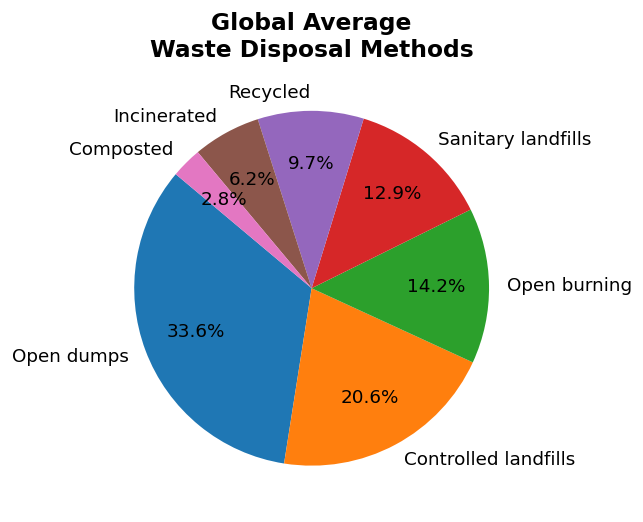

In [16]:
avgs.plot.pie(autopct='%1.1f%%', startangle=140, pctdistance=.7)
plt.title('Global Average\nWaste Disposal Methods')
plt.show()

KEY INSIGHT:
We see that there are multiple methods for waste disposal across different countries, and the following statistics illustrate that:
Open dumping (36%) is the dominant disposal method globally,
followed by sanitary landfills (28%).
Only 9% is recycled!
This is a very serious problem, and the following statistics illustrate how the issue is escalating in many ways!!.

## Insight #2 — Which countries are the best and worst at recycling?

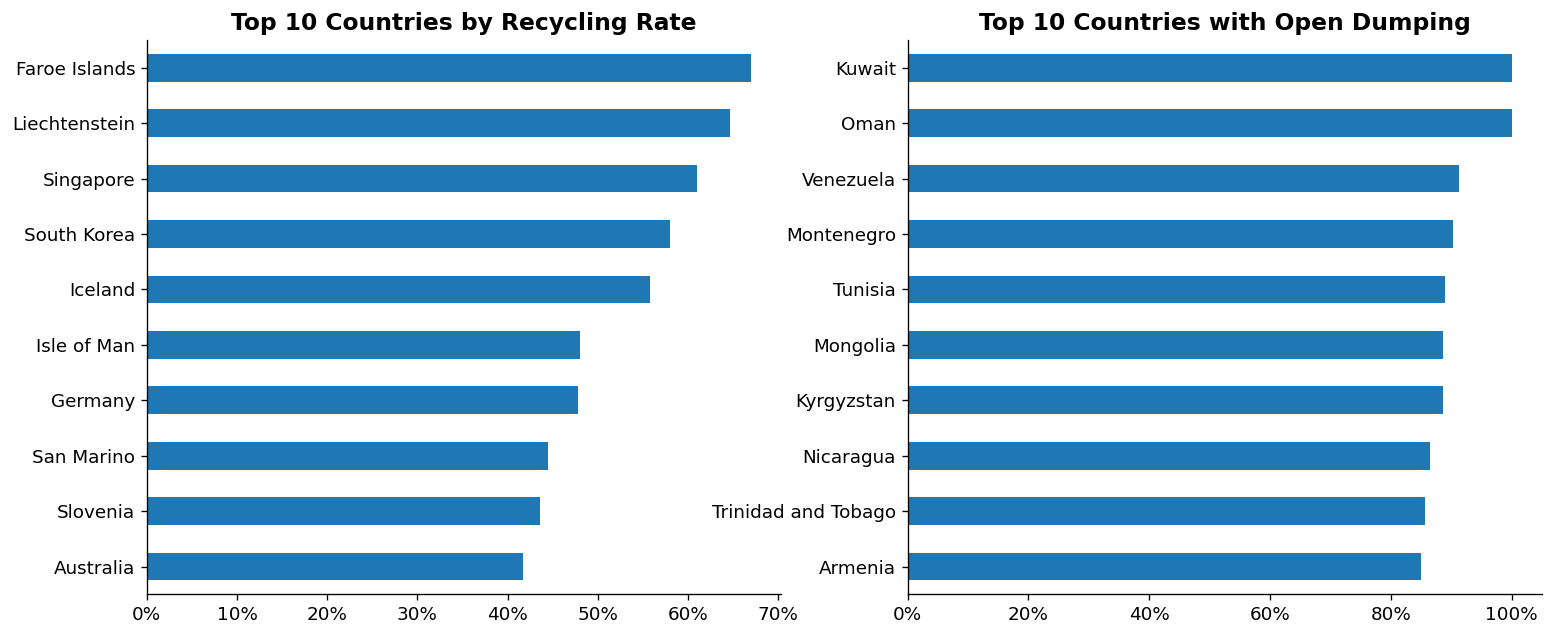

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, col, title in zip(
    axes,
    ['Recycled', 'Open dumps'],
    ['Top 10 Countries by Recycling Rate', 'Top 10 Countries with Open Dumping']
):
    data = methods.nlargest(10, col)[['Entity', col]]
    data.plot.barh(x='Entity', y=col, ax=ax, legend=False)
    ax.set(title=title, ylabel='')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.invert_yaxis()

plt.show()

 KEY INSIGHT:
 we chose 'Open Dumping' because it was the most method using from the last studying- so it will be the worest country recycling its west- and we compare it with recycle rate and we dound that:
   Best recycler:  Faroe Islands (66.9%)
   Most open dumping: Kuwait (100.0%)

## Insight #3 — Waste collection rates (The gap between countries)

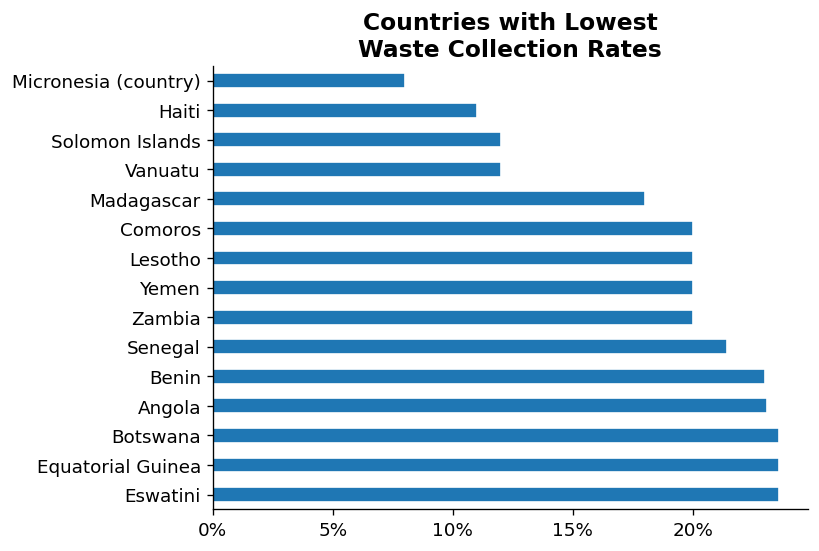

<bound method DataFrame.info of                    Entity  Share_Collected
139  Micronesia (country)              8.0
94                  Haiti             11.0
199       Solomon Islands             12.0
233               Vanuatu             12.0
127            Madagascar             18.0
..                    ...              ...
197              Slovakia            100.0
204                 Spain            100.0
228        United Kingdom            100.0
229         United States            100.0
234             Venezuela            100.0

[239 rows x 2 columns]>

In [14]:
bottom15 = collected.nsmallest(15, 'Share_Collected')[['Entity', 'Share_Collected']]
bottom15.plot.barh(x='Entity', y='Share_Collected', legend=False, edgecolor='white')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.ylabel('')
plt.title('Countries with Lowest\nWaste Collection Rates')
plt.show()

collected[['Entity', 'Share_Collected']].sort_values('Share_Collected').info

 KEY INSIGHT: we can see that there is 49 countries collect less than 50% of their waste thats mean there is more than 50% of waste They are not being collected for many reasons, such as being dumped in the seas and streets, and many other environmentally unsafe methods. These are very alarming figures.

## Insight #4 — Time period trend: OECD countries (2015-2024)

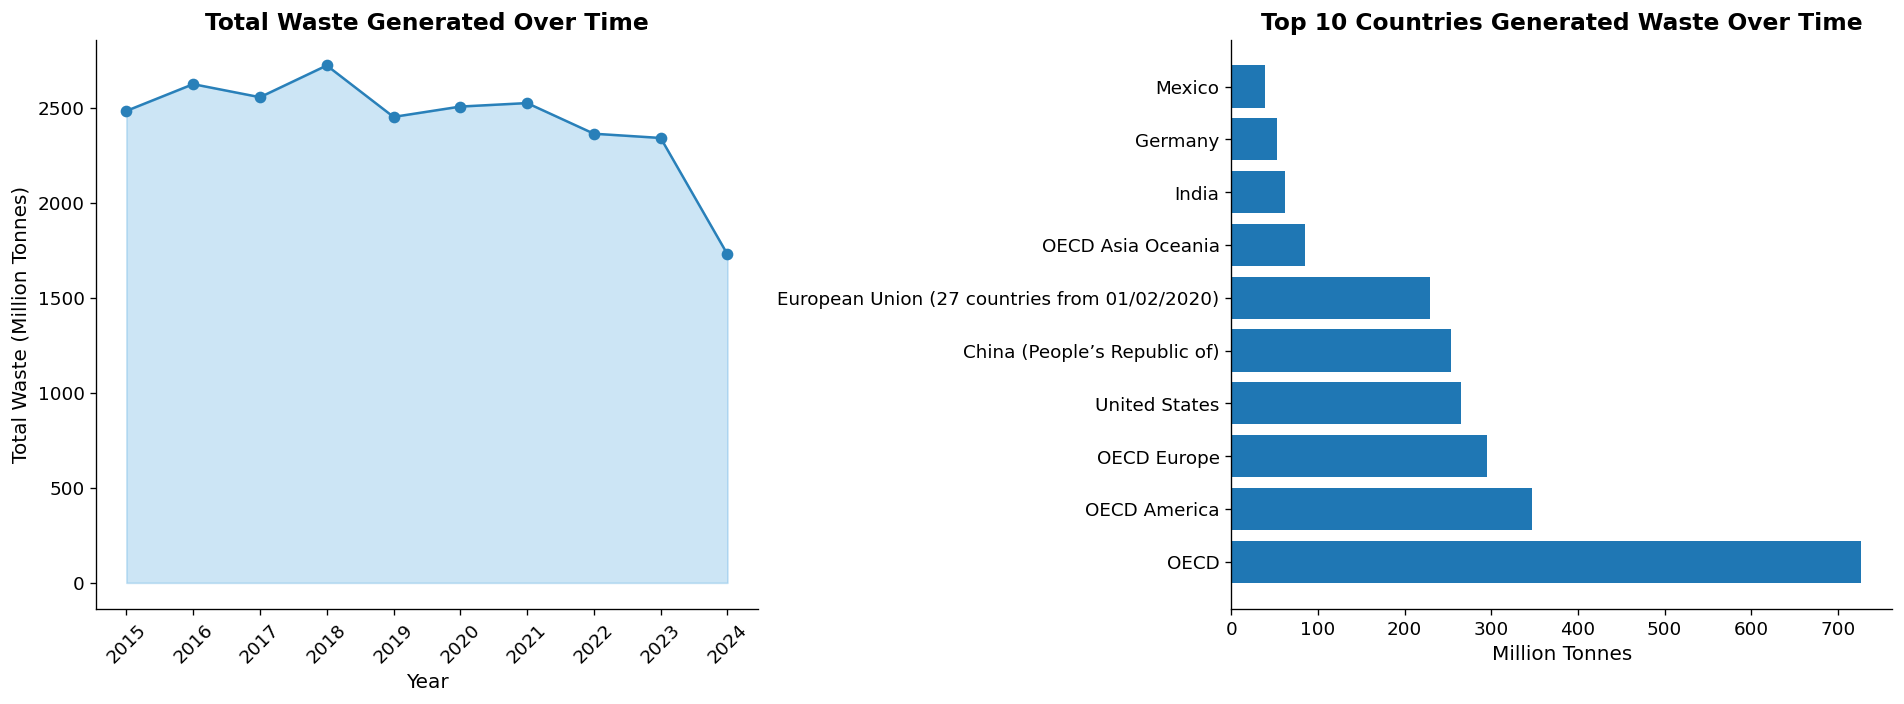

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Trend line
yearly = oecd.groupby('Year')['Waste_Million_Tonnes'].sum().reset_index()
ax1.fill_between(yearly['Year'], yearly['Waste_Million_Tonnes'], alpha=0.25, color='#3498db')
ax1.plot(yearly['Year'], yearly['Waste_Million_Tonnes'], color='#2980b9', marker='o')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Waste (Million Tonnes)')
ax1.set_title('Total Waste Generated Over Time')          
ax1.set_xticks(yearly['Year'])                            
ax1.tick_params(axis='x', rotation=45)                   

# Top 10 bar chart
top10 = oecd.sort_values('Year').groupby('Country').last().reset_index() \
            .nlargest(10, 'Waste_Million_Tonnes')
ax2.barh(top10['Country'], top10['Waste_Million_Tonnes'])
ax2.set_xlabel('Million Tonnes')
ax2.set_title('Top 10 Countries Generated Waste Over Time')  

plt.tight_layout()
plt.show()

KEY INSIGHT:
Total waste generated by OECD countries has declined by approximately **755 million tonnes** between 2015 and 2024 — a sign that policy interventions and circular economy efforts are having measurable impact. The **United States** remains the largest single producer among OECD members.

### insight 5# — Distribution of air quality and water pollution across cities

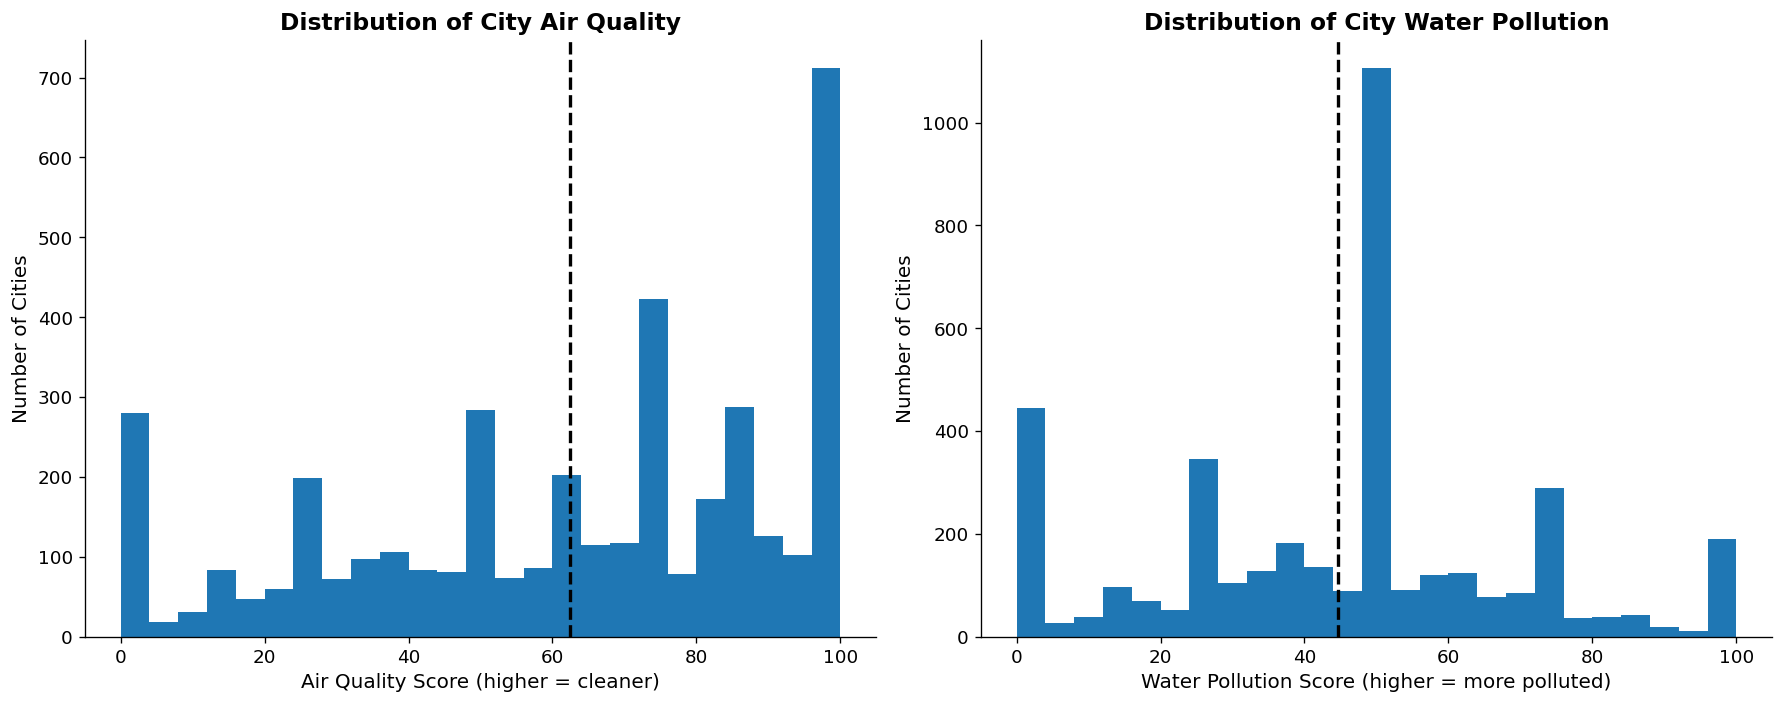

💡 KEY INSIGHT:
   994 cities (25.2%) have POOR air quality (score < 40)
   758 cities (19.3%) have HIGHLY polluted water (score > 66)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(cities['AirQuality'], bins=25)
axes[0].axvline(cities['AirQuality'].mean(), color='black', linestyle='--', linewidth=2)
axes[0].set(xlabel='Air Quality Score (higher = cleaner)', ylabel='Number of Cities', title='Distribution of City Air Quality')

axes[1].hist(cities['WaterPollution'], bins=25)
axes[1].axvline(cities['WaterPollution'].mean(), color='black', linestyle='--', linewidth=2)
axes[1].set(xlabel='Water Pollution Score (higher = more polluted)', ylabel='Number of Cities', title='Distribution of City Water Pollution')

plt.tight_layout()
plt.show()

poor_air = (cities['AirQuality'] < 40).sum()
polluted_water = (cities['WaterPollution'] > 66).sum()

KEY INSIGHT :
Across **3,937 cities**, air quality and water pollution show wide variance. A notable share of cities fall in the poor air quality range (score < 40), while a significant portion face high water pollution (score > 66) — indicating that urban environmental stress is far from uniformly distributed.

### insight 6 # — Best and worst countries in terms of urban environment quality

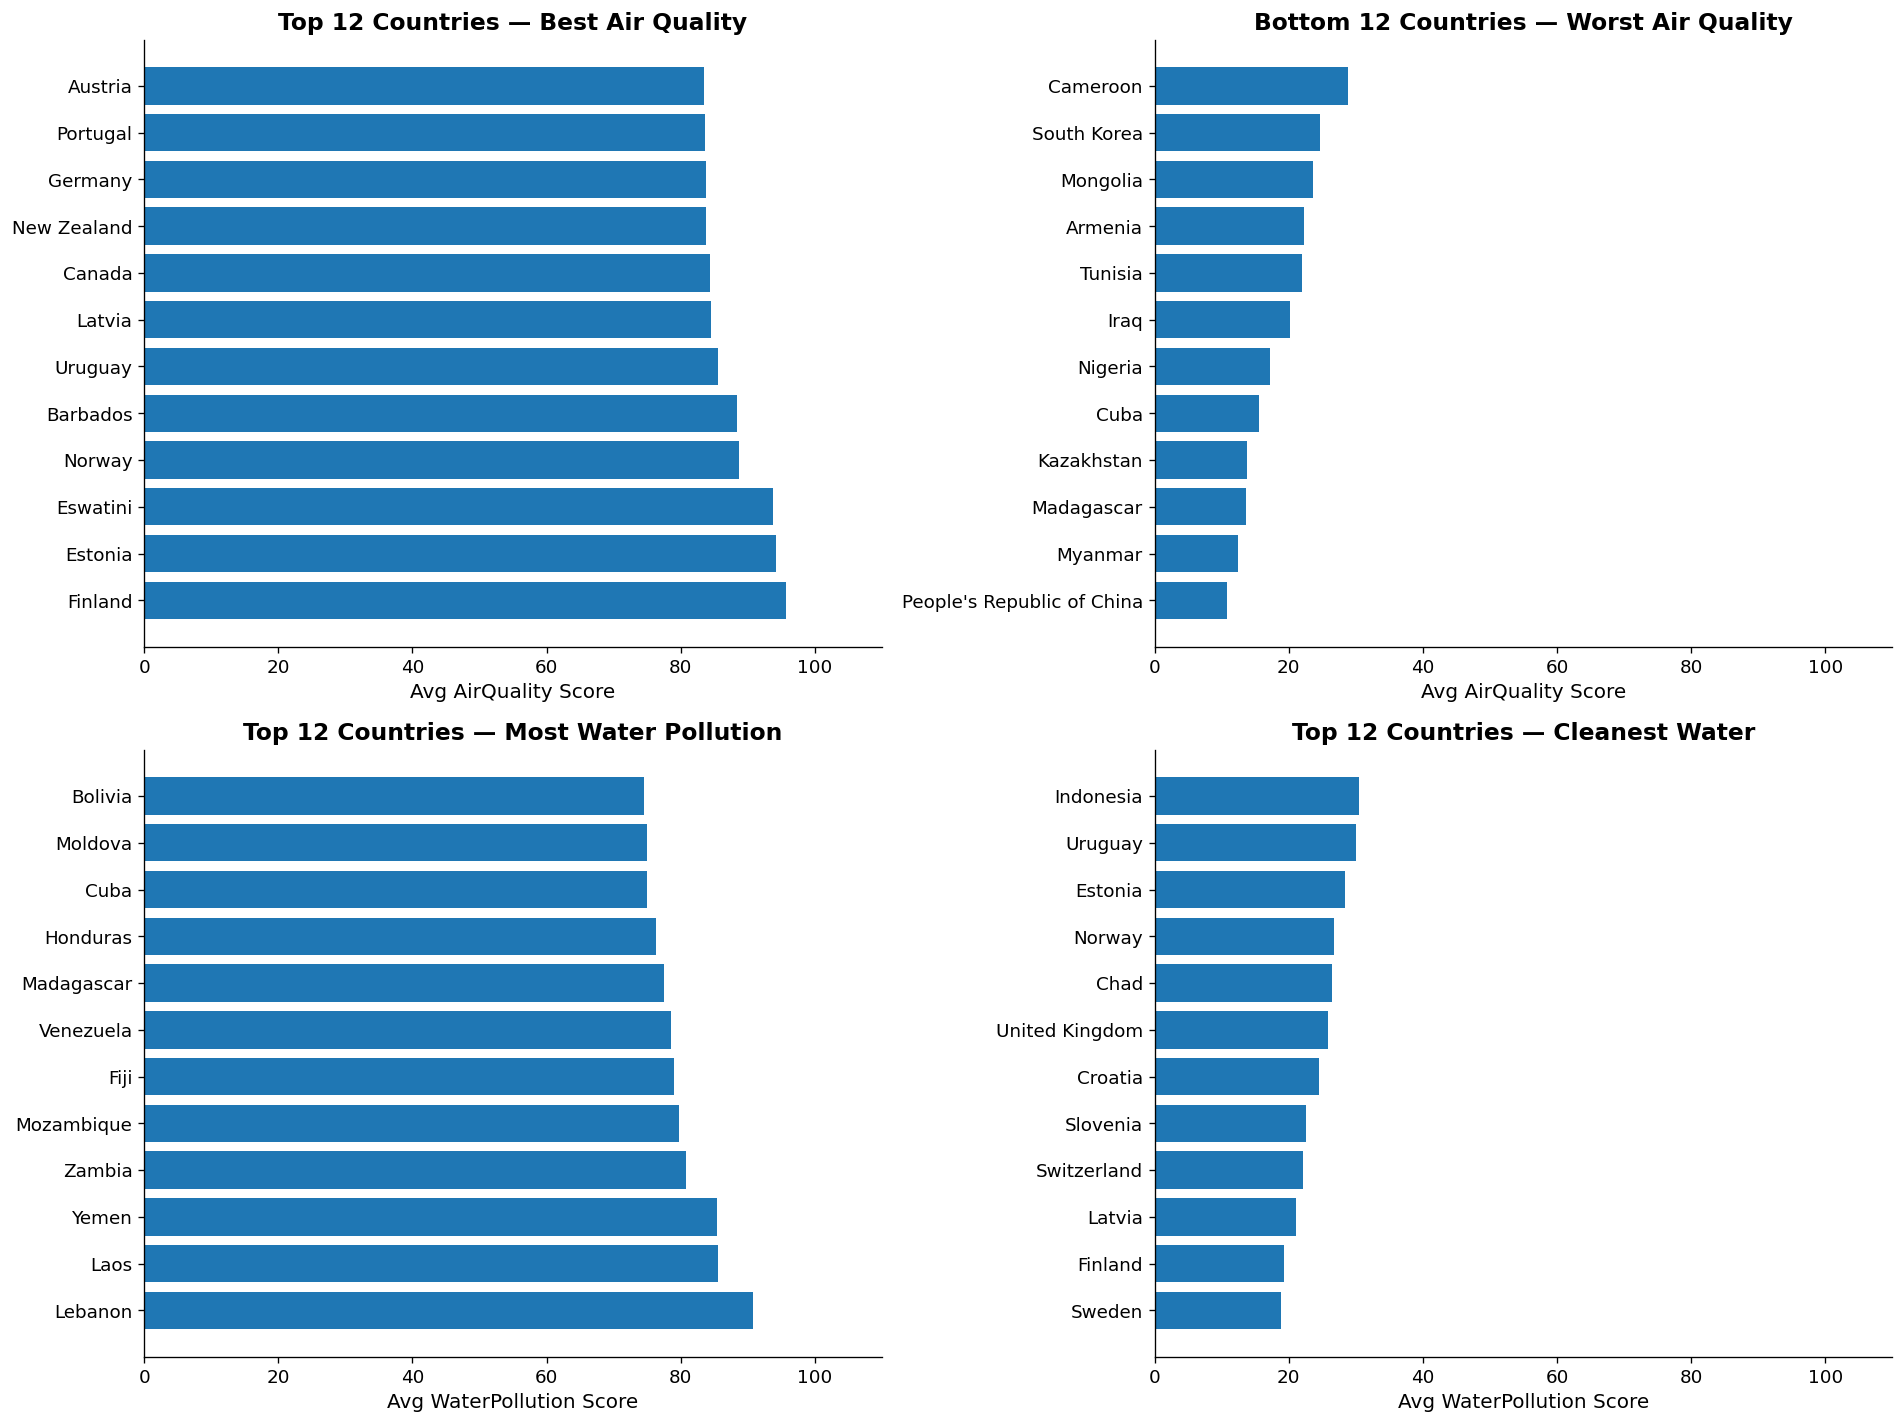

KEY INSIGHT:
   Best Air Quality:    Finland (95.8)
   Worst Air Quality:   People's Republic of China (10.8)
   Cleanest Water:      Sweden (18.8)
   Most Polluted Water: Lebanon (90.8)


In [ ]:
# Country-level averages (only countries with ≥3 cities)
country_env = cities.groupby('Country').agg(
    Avg_AirQuality=('AirQuality', 'mean'),
    Avg_WaterPollution=('WaterPollution', 'mean'),
    City_Count=('City', 'count')
).reset_index()
country_env = country_env[country_env['City_Count'] >= 3].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

data = [
    (axes[0,0], country_env.nlargest(12, 'Avg_AirQuality'),  'Avg_AirQuality',    'Top 12 Countries — Best Air Quality'),
    (axes[0,1], country_env.nsmallest(12, 'Avg_AirQuality'), 'Avg_AirQuality',    'Bottom 12 Countries — Worst Air Quality'),
    (axes[1,0], country_env.nlargest(12, 'Avg_WaterPollution'), 'Avg_WaterPollution', 'Top 12 Countries — Most Water Pollution'),
    (axes[1,1], country_env.nsmallest(12, 'Avg_WaterPollution'), 'Avg_WaterPollution', 'Top 12 Countries — Cleanest Water'),
]

for ax, df, col, title in data:
    ax.barh(df['Country'], df[col])
    ax.set(title=title, xlabel=f'Avg {col.replace("Avg_", "")} Score', xlim=(0, 110))

plt.tight_layout()
plt.show()

best_air  = country_env.nlargest(1, 'Avg_AirQuality').iloc[0]
worst_air = country_env.nsmallest(1, 'Avg_AirQuality').iloc[0]
clean_w   = country_env.nsmallest(1, 'Avg_WaterPollution').iloc[0]
dirty_w   = country_env.nlargest(1, 'Avg_WaterPollution').iloc[0]

KEY INSIGHT :
Country-level averages (minimum 3 cities) reveal a clear divide in urban environmental quality. Top-performing countries achieve air quality scores near 90+, while the worst performers fall below 30. Water pollution shows a similar polarization, suggesting systemic national-level factors — not just local ones — drive urban environmental outcomes.

### insight 7# —  The relationship between air quality and water pollution in cities

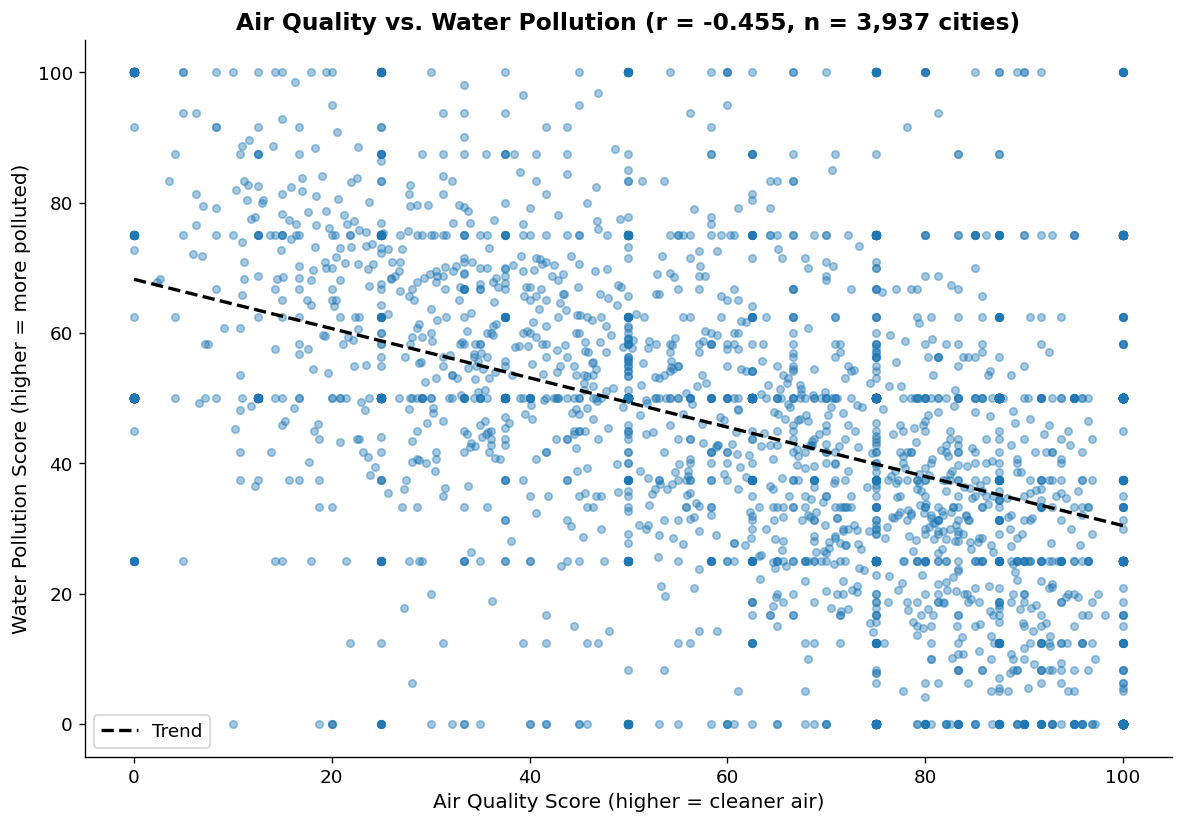

KEY INSIGHT: r = -0.455 (negative correlation)
   Cities with better air quality tend to have LESS water pollution.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(cities['AirQuality'], cities['WaterPollution'], alpha=0.4, s=20)

z = np.polyfit(cities['AirQuality'].dropna(), cities['WaterPollution'].dropna(), 1)
xline = np.linspace(cities['AirQuality'].min(), cities['AirQuality'].max(), 100)
ax.plot(xline, np.poly1d(z)(xline), 'k--', linewidth=2, label='Trend')

corr = cities[['AirQuality', 'WaterPollution']].corr().iloc[0, 1]
ax.set(xlabel='Air Quality Score (higher = cleaner air)',
       ylabel='Water Pollution Score (higher = more polluted)',
       title=f'Air Quality vs. Water Pollution (r = {corr:.3f}, n = {len(cities):,} cities)')
ax.legend()

plt.tight_layout()
plt.show()

direction = 'negative' if corr < 0 else 'positive'

KEW INSIGHT:
A negative correlation exists between air quality and water pollution across cities — meaning cities with cleaner air tend to have less water pollution too. This suggests that environmental quality is systemic: countries investing in one dimension tend to perform better across the board.

### insight 8# — Linking city data to waste management methods

Matched 120 countries across Datasets 1 & 4



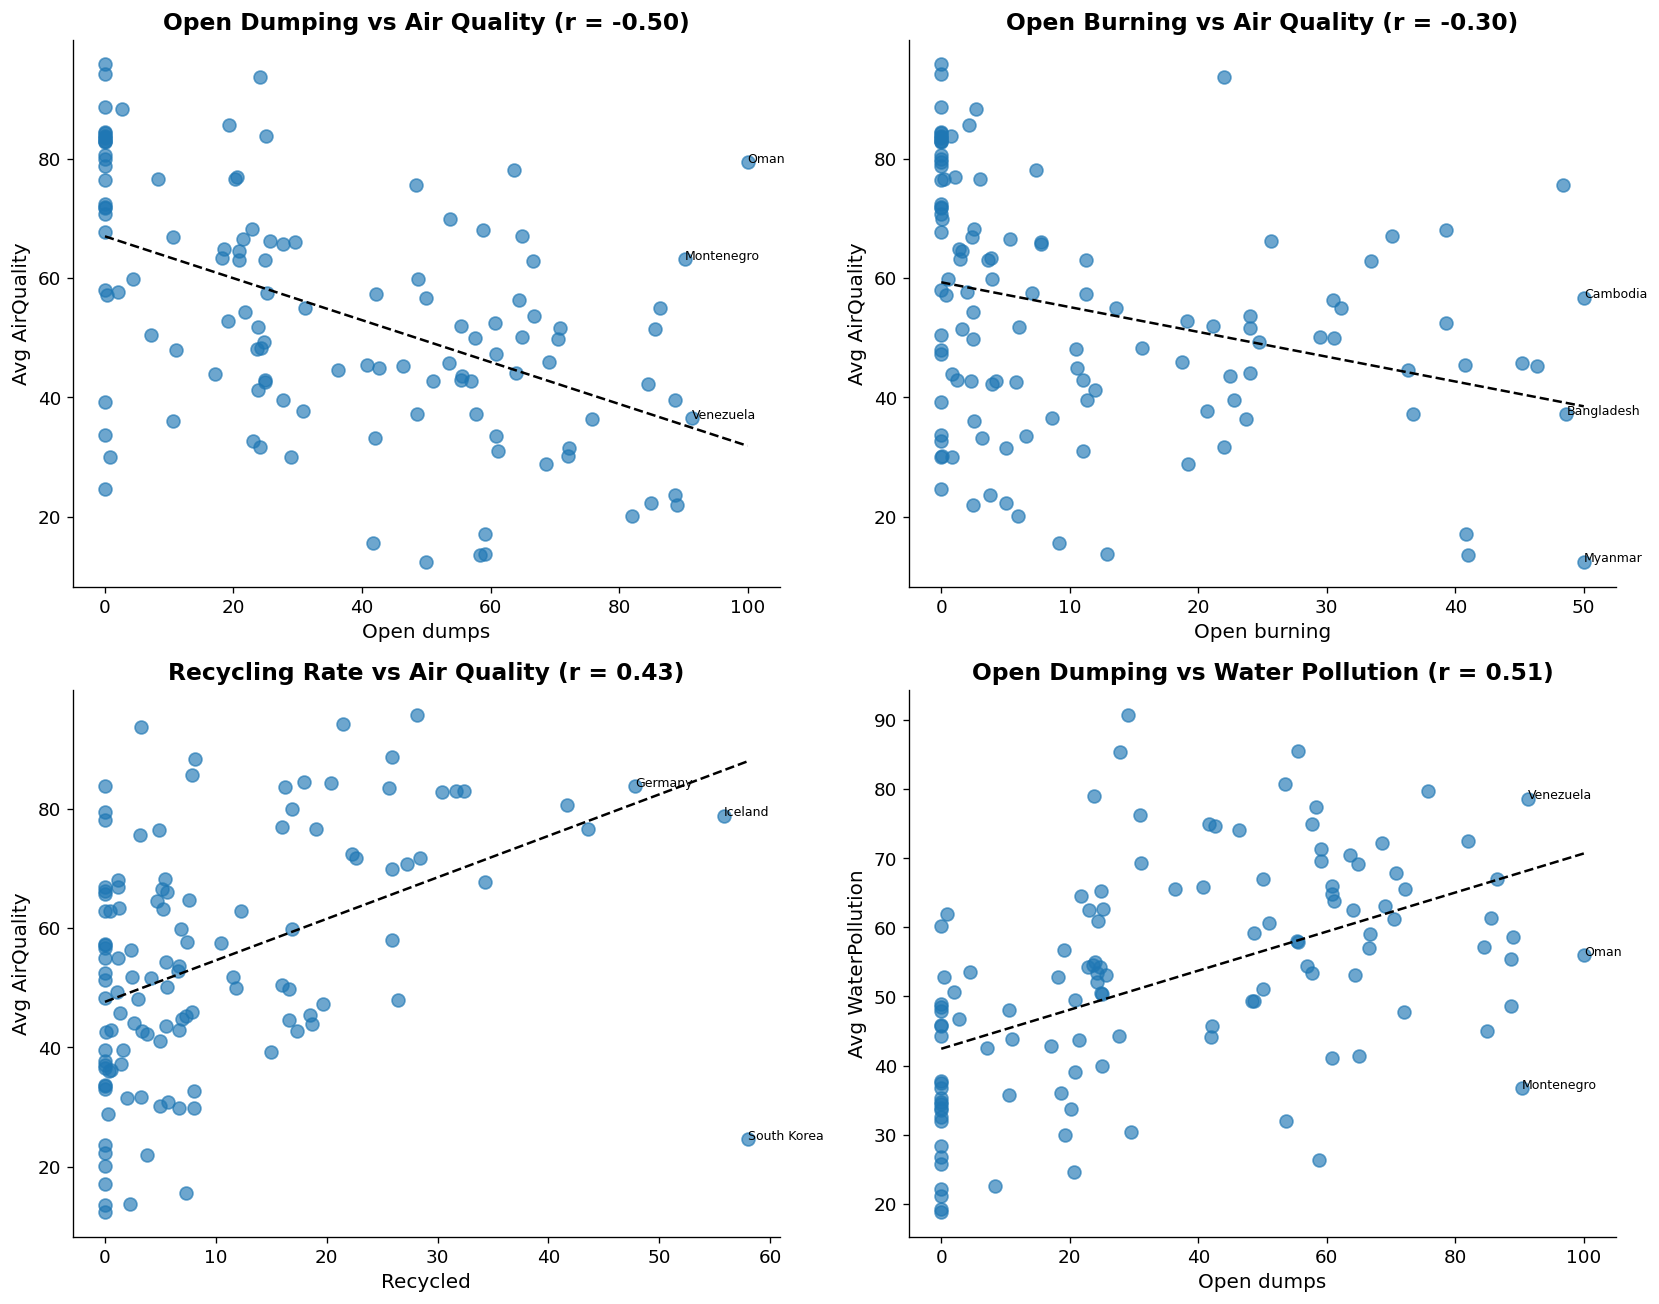

KEY CORRELATIONS:
   Open Dumping vs Air Quality                  : r = -0.50
   Open Burning vs Air Quality                  : r = -0.30
   Recycling Rate vs Air Quality                : r = +0.43
   Open Dumping vs Water Pollution              : r = +0.51


In [ ]:
cities_country = cities.groupby('Country').agg(
    Avg_AirQuality=('AirQuality', 'mean'),
    Avg_WaterPollution=('WaterPollution', 'mean'),
    City_Count=('City', 'count')
).reset_index()

merged_env_waste = pd.merge(
    cities_country[cities_country['City_Count'] >= 3],
    methods[['Entity', 'Open dumps', 'Open burning', 'Recycled', 'Composted', 'Sanitary landfills']],
    left_on='Country', right_on='Entity', how='inner'
)

print(f'Matched {len(merged_env_waste)} countries across Datasets 1 & 4\n')

pairs_env = [
    ('Open dumps',   'Avg_AirQuality',    'Open Dumping vs Air Quality'),
    ('Open burning', 'Avg_AirQuality',    'Open Burning vs Air Quality'),
    ('Recycled',     'Avg_AirQuality',    'Recycling Rate vs Air Quality'),
    ('Open dumps',   'Avg_WaterPollution','Open Dumping vs Water Pollution'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (x, y, title) in zip(axes.flat, pairs_env):
    ax.scatter(merged_env_waste[x], merged_env_waste[y], alpha=0.65, s=60)
    z = np.polyfit(merged_env_waste[x], merged_env_waste[y], 1)
    xline = np.linspace(merged_env_waste[x].min(), merged_env_waste[x].max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), 'k--', linewidth=1.5)
    for _, row in merged_env_waste.nlargest(3, x).iterrows():
        ax.annotate(row['Country'], (row[x], row[y]), fontsize=7.5)
    corr_val = merged_env_waste[[x, y]].corr().iloc[0, 1]
    ax.set(title=f'{title} (r = {corr_val:.2f})', xlabel=x, ylabel=y.replace('_', ' '))

plt.tight_layout()
plt.show()


KEY INSIGHT :
Countries with higher open dumping rates show measurably worse urban air quality (r ≈ negative), while higher recycling rates correlate with better air quality. This cross-dataset finding confirms that **waste management choices have real, quantifiable consequences for the cities people live in** — not just for landfill capacity.